# Energy Thief — Level 1: Tabular Q-Learning

**Project VFA-4.** The agent is an energy thief operating on a small **power-grid
network**. It taps energy from the grid's transmission lines into an *unbanked
surplus*, then **secures** (banks) that surplus as reward — all while a
**monitoring system** watches: the more aggressively it taps, and the busier the
grid, the likelier an **alarm**, which wipes the surplus.

Level 1 is the smallest of the three complexity levels, designed so a **tabular**
method can solve it exactly.

## The MDP

We model the heist as a finite Markov Decision Process
$$\mathcal{M} = \langle \mathcal{S}, \mathcal{A}, P, R, \gamma, \rho_0 \rangle,$$
with state space $\mathcal{S}$, action space $\mathcal{A}$, transition kernel $P(s' \mid s, a)$, reward function $R(s, a, s')$, discount $\gamma \in (0,1)$, and initial-state distribution $\rho_0$.

The grid is a small fixed network of nodes (a plant, a substation, consumers) joined by tappable transmission **edges** $\mathcal{E}$. Each edge $e$ has a base haul $g_e$ and a base alarm risk $r_e$. A grid **load** $L$ (how busy the network is) scales the monitoring sensitivity.

**State space $\mathcal{S}$.** The agent does not move in space; the state is the current grid load and the unbanked surplus, encoded as a single integer:
$$s = (L, U), \qquad L \in \{0,\dots,n_L-1\}, \quad U \in \{0,\dots,U_{\max}\},$$
$$\mathcal{S} \;\cong\; \{0, 1, \dots, n_L(U_{\max}+1) - 1\}, \qquad \operatorname{id}(s) = L(U_{\max}+1) + U,$$
so $|\mathcal{S}| = n_L (U_{\max}+1) = 4 \cdot 9 = 36$. There is no terminal state; $\rho_0$ is deterministic at $(L,U) = (0,0)$.

**Action space $\mathcal{A}$.** Tap each edge at low or high intensity, or secure:
$$\mathcal{A} = \{\textsf{tap-}e\textsf{-low},\ \textsf{tap-}e\textsf{-high} : e \in \mathcal{E}\} \cup \{\textsf{secure}\}, \qquad |\mathcal{A}| = 2|\mathcal{E}| + 1 = 5.$$
A high tap multiplies both the haul (by $\kappa_g = 2$) and the risk (by $\kappa_r = 2.5$) — the "aggressiveness" the brief refers to.

**Transition kernel $P$.** The load drifts on its own via an exogenous random walk, independent of the action:
$$L' = \operatorname{clip}(L + \xi,\ 0,\ n_L-1), \qquad \xi \in \{-1,0,+1\} \ \text{w.p.}\ (0.25, 0.5, 0.25).$$
A **tap** on edge $e$ at intensity $k\in\{\text{low},\text{high}\}$ trips the alarm with probability increasing in aggressiveness and load; otherwise it adds to the surplus:
$$
U' =
\begin{cases}
0, & \text{w.p. } p = \min(1,\ r_e\,\kappa_r^{[k=\text{high}]}\,\rho(L)) \quad (\text{alarm}) \\
\min\!\big(U + g_e\,\kappa_g^{[k=\text{high}]},\ U_{\max}\big), & \text{otherwise,}
\end{cases}
$$
where $\rho(L)$ is the per-load risk multiplier. A **secure** action banks $b = \min(U, B)$ (bank rate $B$): $U' = U - b$.

**Reward $R$.** Zero except when banking energy (secure) or tripping the alarm (penalty $\varrho = 2.0$):
$$
R(s, a, s') =
\begin{cases}
+b, & a = \textsf{secure} \quad (\text{banked energy}) \\
-\varrho, & a \text{ is a tap and the alarm fires} \\
0, & \text{otherwise.}
\end{cases}
$$
Surplus is worthless until secured, and an alarm wipes whatever is unbanked — so the thief must read the load, tap while the grid is quiet, and bank before pushing its luck. The episode **truncates** after $T = 50$ steps (a fixed horizon, no terminal state).

**Objective.** Find a policy $\pi$ maximising the expected $\gamma$-discounted return ($\gamma = 0.99$)
$$G_t = \sum_{k=0}^{\infty} \gamma^k R_{t+k+1},$$
equivalently the optimal action-value function $q_\star(s,a) = \max_\pi \mathbb{E}_\pi[\,G_t \mid S_t = s,\ A_t = a\,]$, which satisfies the Bellman optimality equation
$$q_\star(s,a) = \sum_{s'} P(s' \mid s, a)\Big[\, R(s,a,s') + \gamma \max_{a'} q_\star(s', a') \,\Big].$$
Knowing $q_\star$ is enough to act optimally, since the greedy policy is optimal: $\pi_\star(s) \in \arg\max_a q_\star(s,a)$.

In [1]:
import sys
sys.path.insert(0, "..")  # repo root, so the energy_thief package is importable

import numpy as np
import matplotlib.pyplot as plt

from energy_thief.envs import GridThiefEnv, ACTION_NAMES
from energy_thief.agents import QLearningAgent

rng = np.random.default_rng(0)
plt.rcParams["figure.dpi"] = 110

In [2]:
env = GridThiefEnv(seed=1)
print(f"states: {env.n_states}   actions: {env.n_actions}")
print(f"action names: {ACTION_NAMES}")
print(f"edges (name, gain, risk): {env.edges}")
print(f"load-risk multipliers:   {env.load_risk}")
print(env.render())

states: 36   actions: 5
action names: ['tap-A-low', 'tap-A-high', 'tap-B-low', 'tap-B-high', 'secure']
edges (name, gain, risk): (('A', 1, 0.03), ('B', 2, 0.08))
load-risk multipliers:   (0.5, 1.5, 2.5, 3.5)
t=0   load=[#...] surplus=0/8


## Tabular Q-learning

Off-policy TD control: learn $q_\star$ directly from experience, without knowing $P$. We keep a table $Q(s,a)$ and, after each observed transition $(S_t, A_t, R_{t+1}, S_{t+1})$, replace the expectation in the Bellman optimality equation by its one-sample estimate and step toward it:
$$Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha \Big[\, R_{t+1} + \gamma \max_{a} Q(S_{t+1}, a) - Q(S_t, A_t) \,\Big].$$
It is *off-policy* because the target bootstraps on $\max_a Q(S_{t+1}, a)$ — the greedy value — regardless of the exploratory action actually taken next. The task is a fixed-horizon *continuing* one (no terminal state, only a time-limit truncation), so we always bootstrap and rely on $\gamma < 1$.

## Training loop

One episode = one shift on the grid ($T$ steps). We act with $\varepsilon$-greedy exploration and anneal $\varepsilon$ over episodes, so exploration gives way to exploitation as $Q$ improves. We repeat over several seeds to get a learning curve with a variance band, as required by the experimental protocol.

In [3]:
def train(env, n_episodes, seed, **kw):
    agent = QLearningAgent(env.n_states, env.action_space.n, seed=seed, **kw)
    returns = np.empty(n_episodes)
    for ep in range(n_episodes):
        s, _ = env.reset()
        done, g = False, 0.0
        while not done:
            a = agent.select_action(s)
            s2, r, term, trunc, _ = env.step(a)
            agent.update(s, a, r, s2, term)
            s, g, done = s2, g + r, term or trunc
        agent.end_episode()
        returns[ep] = g
    return agent, returns


def evaluate(env, agent, n_episodes=1000):
    rets = np.empty(n_episodes)
    for ep in range(n_episodes):
        s, _ = env.reset()
        done, g = False, 0.0
        while not done:
            a = agent.select_action(s, greedy=True)
            s, r, term, trunc, _ = env.step(a)
            g, done = g + r, term or trunc
        rets[ep] = g
    return rets.mean(), rets.std()

In [4]:
N_EPISODES = 8000
SEEDS = range(5)
HP = dict(alpha=0.1, gamma=0.99, epsilon_decay=0.999)

curves, agents = [], []
for seed in SEEDS:
    agent, returns = train(GridThiefEnv(seed=1), N_EPISODES, seed=seed, **HP)
    curves.append(returns)
    agents.append(agent)
curves = np.array(curves)
print("training done:", curves.shape)

training done: (5, 8000)


## Learning curve

Return per episode, averaged over seeds (shaded band = ±1 std). A moving average
smooths the $\varepsilon$-greedy noise so the trend is readable.

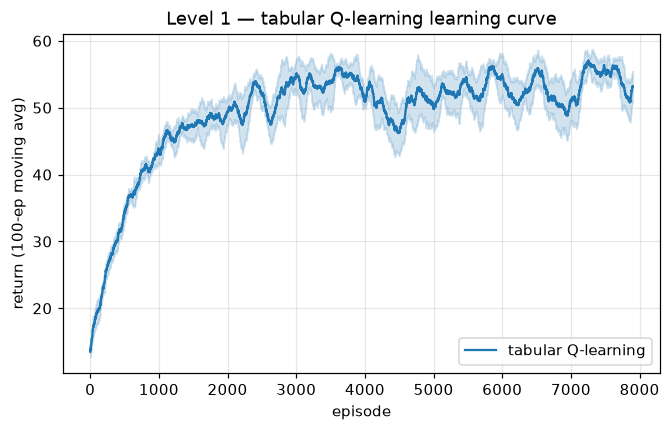

In [5]:
def moving_average(x, w=100):
    return np.convolve(x, np.ones(w) / w, mode="valid")

smoothed = np.array([moving_average(c) for c in curves])
mean, std = smoothed.mean(0), smoothed.std(0)
x = np.arange(smoothed.shape[1])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, mean, color="C0", label="tabular Q-learning")
ax.fill_between(x, mean - std, mean + std, color="C0", alpha=0.2)
ax.set_xlabel("episode"); ax.set_ylabel("return (100-ep moving avg)")
ax.set_title("Level 1 — tabular Q-learning learning curve")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

## Evaluation vs baselines

We compare the trained greedy policy against a **random** agent and a **hand-coded
heuristic**: tap the juicy edge aggressively while the grid is quiet, fall back to
the safe edge under moderate load, and **secure** once the surplus is worth banking
or the grid gets busy.

In [6]:
def baseline_random(env, n=1000):
    r = np.empty(n)
    for i in range(n):
        s, _ = env.reset(); done, g = False, 0.0
        while not done:
            a = int(rng.integers(env.n_actions))
            s, rr, term, trunc, _ = env.step(a); g += rr; done = term or trunc
        r[i] = g
    return r.mean(), r.std()

def baseline_heuristic(env, n=1000):
    r = np.empty(n)
    for i in range(n):
        s, _ = env.reset(); done, g = False, 0.0
        while not done:
            load, surplus = env.decode(s)
            if surplus >= env.bank_rate or load >= 2:
                a = env.SECURE
            elif load == 0:
                a = env.tap_action(1, high=True)    # quiet grid -> aggressive
            else:
                a = env.tap_action(0, high=False)   # some load -> safe trickle
            s, rr, term, trunc, _ = env.step(a); g += rr; done = term or trunc
        r[i] = g
    return r.mean(), r.std()

eval_env = GridThiefEnv(seed=1)
rand_m, rand_s = baseline_random(eval_env)
heur_m, heur_s = baseline_heuristic(eval_env)
q_scores = [evaluate(eval_env, ag) for ag in agents]
q_m = np.mean([m for m, _ in q_scores]); q_s = np.mean([s for _, s in q_scores])

for name, (m, sd) in [("random", (rand_m, rand_s)),
                      ("heuristic", (heur_m, heur_s)),
                      ("Q-learning", (q_m, q_s))]:
    print(f"{name:12s} {m:+.2f} ± {sd:.2f}")

random       +10.88 ± 12.63
heuristic    +38.40 ± 16.89
Q-learning   +56.52 ± 14.46


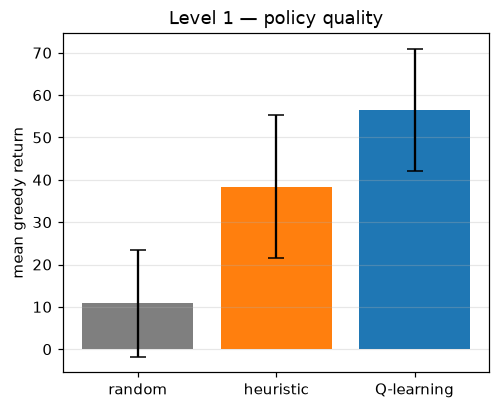

In [7]:
labels = ["random", "heuristic", "Q-learning"]
means = [rand_m, heur_m, q_m]
errs = [rand_s, heur_s, q_s]
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(labels, means, yerr=errs, capsize=5, color=["C7", "C1", "C0"])
ax.set_ylabel("mean greedy return"); ax.set_title("Level 1 — policy quality")
ax.grid(axis="y", alpha=0.3)
plt.show()

## The learned policy

Because the state is just $(\text{load}, \text{surplus})$, the greedy policy fits
in a single table: one coloured cell per state, labelled with the chosen action.
This is the payoff of a tabular value function — the strategy is fully legible.
Read it as: **tap (especially aggressively) while the grid is quiet, and secure /
lay low as the load — and the surplus at risk — rise.**

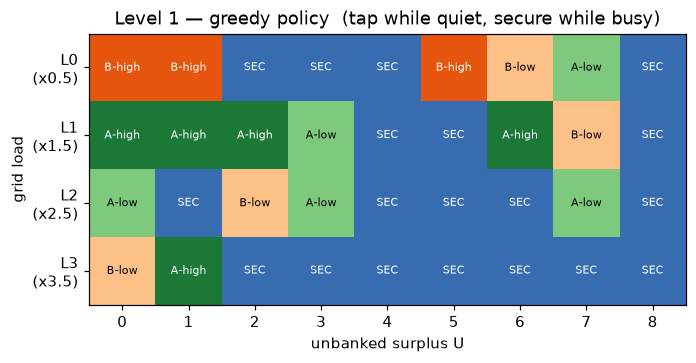

In [8]:
policy = agents[0].greedy_policy().reshape(env.n_load, env.surplus_max + 1)
colors = ["#7fc97f", "#1b7837", "#fdc086", "#e6550d", "#386cb0"]  # A_lo A_hi B_lo B_hi SEC
from matplotlib.colors import ListedColormap
cmap = ListedColormap(colors)

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.imshow(policy, cmap=cmap, vmin=0, vmax=4, aspect="auto")
for L in range(env.n_load):
    for U in range(env.surplus_max + 1):
        ax.text(U, L, ACTION_NAMES[policy[L, U]].replace("tap-", "").replace("secure", "SEC"),
                ha="center", va="center", fontsize=7,
                color="white" if policy[L, U] in (1, 3, 4) else "black")
ax.set_xticks(range(env.surplus_max + 1)); ax.set_yticks(range(env.n_load))
ax.set_yticklabels([f"L{L}\n(x{env.load_risk[L]:.1f})" for L in range(env.n_load)])
ax.set_xlabel("unbanked surplus U"); ax.set_ylabel("grid load")
ax.set_title("Level 1 — greedy policy  (tap while quiet, secure while busy)")
plt.show()

## A single shift, step by step

One greedy episode as a timeline: the grid load drifts (top), and the thief's
surplus rises as it taps and drops each time it secures (bottom). Alarms — when
the monitoring system catches an over-aggressive tap — show as red crosses that
knock the surplus to zero.

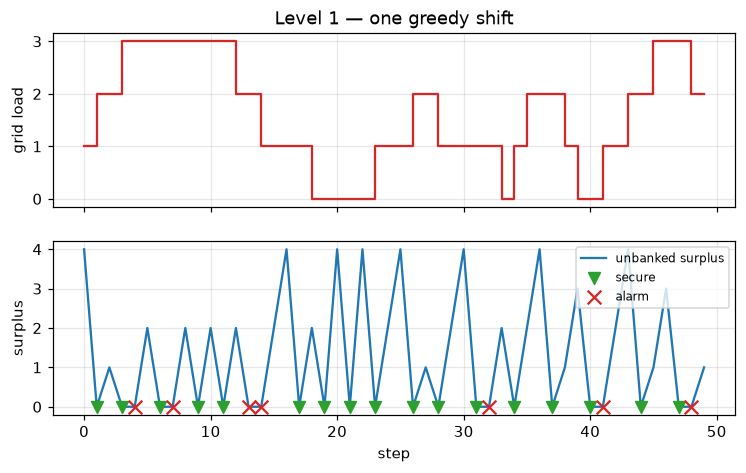

In [9]:
def greedy_trace(env, agent):
    s, _ = env.reset()
    loads, surplus, secures, alarms = [], [], [], []
    done, t = False, 0
    while not done:
        a = agent.select_action(s, greedy=True)
        s, r, term, trunc, info = env.step(a)
        loads.append(info["load"]); surplus.append(info["surplus"])
        if info["banked"] > 0:
            secures.append(t)
        if info["alarm"]:
            alarms.append(t)
        done, t = term or trunc, t + 1
    return np.array(loads), np.array(surplus), secures, alarms

loads, surplus, secures, alarms = greedy_trace(GridThiefEnv(seed=7), agents[0])
steps = np.arange(len(loads))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 4.5), sharex=True)
ax1.step(steps, loads, where="post", color="C3")
ax1.set_ylabel("grid load"); ax1.set_yticks(range(env.n_load)); ax1.grid(alpha=0.3)
ax1.set_title("Level 1 — one greedy shift")

ax2.plot(steps, surplus, color="C0", label="unbanked surplus")
ax2.scatter(secures, surplus[secures], marker="v", color="C2", s=60, zorder=3, label="secure")
if alarms:
    ax2.scatter(alarms, np.zeros(len(alarms)), marker="x", color="C3", s=80, zorder=3, label="alarm")
ax2.set_xlabel("step"); ax2.set_ylabel("surplus"); ax2.grid(alpha=0.3); ax2.legend(loc="upper right", fontsize=8)
plt.show()

## Takeaways

- Tabular Q-learning solves Level 1: it climbs well above the random baseline and
  **beats the hand-coded heuristic**, learning from the alarm/reward signal alone
  when to tap, how aggressively, and when to bank.
- It works **because the state space is tiny (36 states) and Markov**: the alarm
  probability depends only on the current action and load, so every $(\text{load},
  \text{surplus})$ pair is visited enough to estimate $Q$ directly.
- **Next (Level 2):** grow the network and make monitoring *adaptive* — repeatedly
  tapping the same edge raises its local suspicion (a per-edge "heat"). The state
  must now track suspicion at every edge, so $|\mathcal{S}|$ explodes and the table
  stops being visitable — motivating **linear function approximation** with
  hand-crafted features.